# Linear System Test of the Trajectory Manifold Learn Controller

In [21]:
import torch
import numpy as np

device = torch.device("cuda")
W = None
x_dim = 4
u_dim = 1
H = 10
spectral_radius = 0.9
seed=234
np.random.seed(seed)

x0 = np.zeros(x_dim)
x0[0] = 1.0
x_ref = np.random.randn(x_dim)
u_ref = np.random.randn(u_dim)

Q = np.eye(x_dim)
R = np.eye(u_dim)
x_ref_t = torch.tensor(x_ref, dtype=torch.float32, device=device)
u_ref_t = torch.tensor(u_ref, dtype=torch.float32, device=device)

w_dim = (H + 1) * x_dim + H * u_dim



## Sample Controllable System

In [4]:
from src.linear_system import sample_controllable_linear_system, is_controllable

A, B = sample_controllable_linear_system(
        x_dim,
        u_dim,
        spectral_radius=spectral_radius,
        seed=seed,
)
rank, controllable = is_controllable(A, B)
print(f"  controllability rank={rank}, full={controllable}")

  controllability rank=4, full=True


## Generate System Trajectories

In [1]:
import importlib
import src.linear_system
importlib.reload(src.linear_system)

<module 'src.linear_system' from 'c:\\Users\\bayer\\PycharmProjects\\koopman\\src\\linear_system.py'>

In [5]:
num_steps = 100
n_repeats = 100
process_noise_std = 0.0

In [6]:
from src.linear_system import generate_linear_trajectory_data
from src.manifold_control import build_trajectory_training_matrix

_, X_all, U_all = generate_linear_trajectory_data(
    A,
    B,
    num_steps=num_steps,
    n_repeats=n_repeats,
    process_noise_std=process_noise_std,
    seed=seed,
)

W = build_trajectory_training_matrix(
    X_all,
    U_all,
    horizon=H,
    device=device,
    dtype=torch.float32,
)
w_dim = W.shape[1]
print(f"  training matrix shape={tuple(W.shape)}")

  training matrix shape=(9100, 54)


## Train Test Split 

In [1]:
test_fraction=0.2
rank_tol=None

In [7]:
from src.manifold_control import split_behavior_matrix, behavior_matrix_rank_summary

W_train, W_test = split_behavior_matrix(
    W, test_fraction=0.2, seed=seed
)
summaries = {
    "W_all": behavior_matrix_rank_summary(W, tol=rank_tol),
    "W_train": behavior_matrix_rank_summary(W_train, tol=rank_tol),
    "W_test": behavior_matrix_rank_summary(W_test, tol=rank_tol),
}
print("behavior matrix:")
for name, summary in summaries.items():
    print(
        f"  {name} shape={summary['shape']}, "
        f"uncentered rank={summary['rank']}, "
        f"centered rank={summary['centered_rank']}"
    )
    singular_values = np.asarray(summary["leading_singular_values"])
    print(
        "    leading singular values="
        f"{np.array2string(singular_values, precision=3)}"
    )
expected_behavior_dim = x_dim + H * u_dim
print(
    "  expected noiseless behavior dimension="
    f"n + Hm={expected_behavior_dim}"
)
print(
    "  rank tolerance="
    f"{rank_tol if rank_tol is not None else 'NumPy default'}"
)

behavior matrix:
  W_all shape=(9100, 54), uncentered rank=14, centered rank=14
    leading singular values=[216.2   154.665 154.047 150.477 148.872]
  W_train shape=(7280, 54), uncentered rank=14, centered rank=14
    leading singular values=[192.713 138.927 137.453 135.411 133.792]
  W_test shape=(1820, 54), uncentered rank=14, centered rank=14
    leading singular values=[98.216 70.633 68.11  66.768 64.637]
  expected noiseless behavior dimension=n + Hm=14
  rank tolerance=NumPy default


# Train Manifold Decoder

In [9]:
import importlib
import src.manifold_control
importlib.reload(src.manifold_control)

<module 'src.manifold_control' from 'c:\\Users\\bayer\\PycharmProjects\\koopman\\src\\manifold_control.py'>

In [10]:
from pathlib import Path

alpha_dim = 14
hidden_dims = [64, 64]
epochs = 100
max_iter = 1000
train_lr = 1e-3

print_every = 10
checkpoint = Path("saves") / "saved_models" / "behavior_decoder_linear.pt"

In [11]:

from src.manifold_control import train_decoder


autoencoder = train_decoder(
    W_train,
    x_dim=x_dim,
    u_dim=u_dim,
    horizon=H,
    alpha_dim=alpha_dim,
    hidden_dims=hidden_dims,
    epochs=epochs,
    max_iter=max_iter,
    lr=train_lr,
    print_every=print_every,
    checkpoint=checkpoint,
    device=device
)
encoder = autoencoder.encoder
decoder = autoencoder.decoder
encoder.eval()
decoder.eval()

Training W=(7280, 54), method=minibatch, alpha_dim=14, device=cuda
epoch=0000, loss=0.429712, fit=0.429712
epoch=0010, loss=0.011129, fit=0.011129
epoch=0020, loss=0.003430, fit=0.003430
epoch=0030, loss=0.002203, fit=0.002203
epoch=0040, loss=0.001696, fit=0.001696
epoch=0050, loss=0.001374, fit=0.001374
epoch=0060, loss=0.001207, fit=0.001207
epoch=0070, loss=0.001104, fit=0.001104
epoch=0080, loss=0.000995, fit=0.000995
epoch=0090, loss=0.000901, fit=0.000901
saved autoencoder checkpoint to saves\saved_models\behavior_decoder_linear.pt


BehaviorDecoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=54, bias=True)
  )
)

## Prints

In [13]:
from src.manifold_control import evaluate_behavior_autoencoder

def print_autoencoder_metrics(label: str, matrix: "torch.Tensor") -> None:
    metrics = evaluate_behavior_autoencoder(
        encoder,
        decoder,
        matrix,
        A=A,
        B=B,
        x_dim=x_dim,
        u_dim=u_dim,
        horizon=H,
    )
    print(f"{label} autoencoder metrics:")
    print(
        "  reconstruction: "
        f"aggregate NRMSE={metrics['aggregate_nrmse']:.6g}, "
        f"trajectory median={metrics['trajectory_nrmse_median']:.6g}, "
        f"trajectory p95={metrics['trajectory_nrmse_p95']:.6g}, "
        f"R^2={metrics['r2']:.6g}"
    )
    for residual_label, prefix in (
        ("data dynamics residual", "data_dynamics_residual"),
        ("reconstructed dynamics residual", "reconstructed_dynamics_residual"),
    ):
        print(
            f"  {residual_label}: "
            f"mean={metrics[prefix + '_mean']:.6g}, "
            f"median={metrics[prefix + '_median']:.6g}, "
            f"p95={metrics[prefix + '_p95']:.6g}, "
            f"max={metrics[prefix + '_max']:.6g}"
        )

print_autoencoder_metrics("Train", W_train)
print_autoencoder_metrics("Test", W_test)

Train autoencoder metrics:
  reconstruction: aggregate NRMSE=0.0414532, trajectory median=0.0326243, trajectory p95=0.0617703, R^2=0.998282
  data dynamics residual: mean=2.25656e-08, median=2.1518e-08, p95=4.28391e-08, max=7.7699e-08
  reconstructed dynamics residual: mean=0.00364932, median=0.00276472, p95=0.00929901, max=0.0710568
Test autoencoder metrics:
  reconstruction: aggregate NRMSE=0.0409597, trajectory median=0.0325861, trajectory p95=0.0599499, R^2=0.998322
  data dynamics residual: mean=2.25068e-08, median=2.1518e-08, p95=4.25412e-08, max=7.7699e-08
  reconstructed dynamics residual: mean=0.0036738, median=0.00276419, p95=0.00933569, max=0.0948318


In [38]:
from src.manifold_control import train_decoder

decoder = train_decoder(
    W,
    x_dim=x_dim,
    u_dim=u_dim,
    horizon=H,
    alpha_dim=alpha_dim,
    hidden_dims=hidden_dims,
    epochs=epochs,
    max_iter=max_iter,
    lr=train_lr,
    print_every=print_every,
    checkpoint=checkpoint,
    device=device,
)
decoder.eval()

Training W=(9100, 54), alpha_table=(9100, 14), device=cuda
epoch=0000, loss=0.511806, fit=0.511806
epoch=0010, loss=0.338968, fit=0.338968
epoch=0020, loss=0.179703, fit=0.179703
epoch=0030, loss=0.086137, fit=0.086137
epoch=0040, loss=0.037633, fit=0.037633
epoch=0050, loss=0.021822, fit=0.021822
epoch=0060, loss=0.008426, fit=0.008426
epoch=0070, loss=0.004339, fit=0.004339
epoch=0080, loss=0.003837, fit=0.003837
epoch=0090, loss=0.003724, fit=0.003724
saved decoder checkpoint to saves\saved_models\behavior_decoder_linear.pt


BehaviorDecoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=54, bias=True)
  )
)

## Load the trained model

In [ ]:
from src.manifold_control import load_decoder

decoder = load_decoder(
    checkpoint=checkpoint,
    alpha_dim=alpha_dim,
    w_dim=w_dim,
    hidden_dims=hidden_dims,
    device=device,
)

# Solve the Control problem

In [14]:
lambda_theta = 1e1
lambda_curvature = 1.0
solve_lr = 1e-3
u_max = 100.0

## Single Step Control

In [22]:
from src.manifold_control import BehaviorManifoldControlSolver


solver = BehaviorManifoldControlSolver(
        decoder=decoder,
        x_dim=x_dim,
        u_dim=u_dim,
        horizon=H,
        Q=Q,
        R=R,
        x_ref=x_ref,
        u_ref=u_ref,
        lambda_theta=lambda_theta,
        lambda_curvature=lambda_curvature,
        lr=solve_lr,
        max_iter=max_iter,
        u_bounds=(-u_max, u_max),
        curvature_mode="local",
        device=device,
    )

x_init = torch.zeros(H + 1, x_dim, device=device)
x_init[0] = torch.tensor(x0, dtype=torch.float32, device=device)
u_init = torch.zeros(H, u_dim, device=device)
alpha_init = torch.zeros(alpha_dim, device=device)

solution = solver.solve(
    x_init=x_init,
    u_init=u_init,
    alpha_init=alpha_init,
    freeze={"theta": True, "x": False, "u": False, "alpha": False},
)

u_plan = solution.u.detach().cpu().numpy()
print(f"  loss_dict={solution.loss_dict}")
print(f"  first control={u_plan[0]}")

  loss_dict={'qr': 24.627443313598633, 'fit': 0.6078208684921265, 'curvature': 6.807101549100025e-10, 'total': 30.705652236938477, 'iterations': 1000.0}
  first control=[-0.26223332]


## Closed Loop Control

In [56]:
import importlib
import src.linear_system
import src.manifold_control
importlib.reload(src.manifold_control)
importlib.reload(src.linear_system)

<module 'src.linear_system' from 'c:\\Users\\bayer\\PycharmProjects\\koopman\\src\\linear_system.py'>

In [23]:
sim_steps = 25
x_ref_t = torch.tensor(x_ref, dtype=torch.float32, device=device)
u_ref_t = torch.tensor(u_ref, dtype=torch.float32, device=device)
results_path = Path("saves") / "simulation_results" / "linear_manifold_results.npz"
plot_path = Path("saves") / "figures" / "linear_manifold_results.png"

In [24]:
from src.linear_system import simulate_discrete_closed_loop, finite_horizon_lqr_u_caller
from src.manifold_control import make_linear_manifold_u_caller

u_manifold = make_linear_manifold_u_caller(
    decoder=decoder,
    Q=Q,
    R=R,
    x_ref=x_ref_t,
    u_ref=u_ref_t,
    H=H,
    alpha_dim=alpha_dim,
    umax=u_max,
    device=device,
    solve_lr=solve_lr,
    max_iter=max_iter,
    lambda_theta=lambda_theta,
    lambda_curvature=lambda_curvature,
)

X_mani, U_mani = simulate_discrete_closed_loop(
    A,
    B,
    u_manifold,
    x0,
    num_steps=sim_steps,
)

In [25]:
u_lqr = finite_horizon_lqr_u_caller(
    A,
    B,
    Q,
    R,
    horizon=max(sim_steps, H),
    x_ref=x_ref,
    umax=u_max,
)
X_lqr, U_lqr = simulate_discrete_closed_loop(
    A,
    B,
    u_lqr,
    x0,
    num_steps=sim_steps,
)

zero_u = lambda _k, _x: np.zeros(u_dim)
X_zero, U_zero = simulate_discrete_closed_loop(
    A,
    B,
    zero_u,
    x0,
    num_steps=sim_steps,
)

print(f"  final ||x_manifold - x_ref||={np.linalg.norm(X_mani[:, -1] - x_ref):.6f}")
print(f"  final ||x_lqr      - x_ref||={np.linalg.norm(X_lqr[:, -1] - x_ref):.6f}")
print(f"  final ||x_zero     - x_ref||={np.linalg.norm(X_zero[:, -1] - x_ref):.6f}")

  final ||x_manifold - x_ref||=1.683079
  final ||x_lqr      - x_ref||=1.679372
  final ||x_zero     - x_ref||=1.658932


## Save Results

In [60]:
results_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    results_path,
    A=A,
    B=B,
    x0=x0,
    x_ref=x_ref,
    X_manifold=X_mani,
    U_manifold=U_mani,
    X_lqr=X_lqr,
    U_lqr=U_lqr,
    X_zero=X_zero,
    U_zero=U_zero,
)

## Load Results

In [ ]:
with np.load(results_path) as data:
    A = data["A"]
    B = data["B"]
    x0 = data["x0"]
    x_ref = data["x_ref"]
    X_mani = data["X_manifold"]
    U_mani = data["U_manifold"]
    X_lqr = data["X_lqr"]
    U_lqr = data["U_lqr"]
    X_zero = data["X_zero"]
    U_zero = data["U_zero"]

## Plot Results

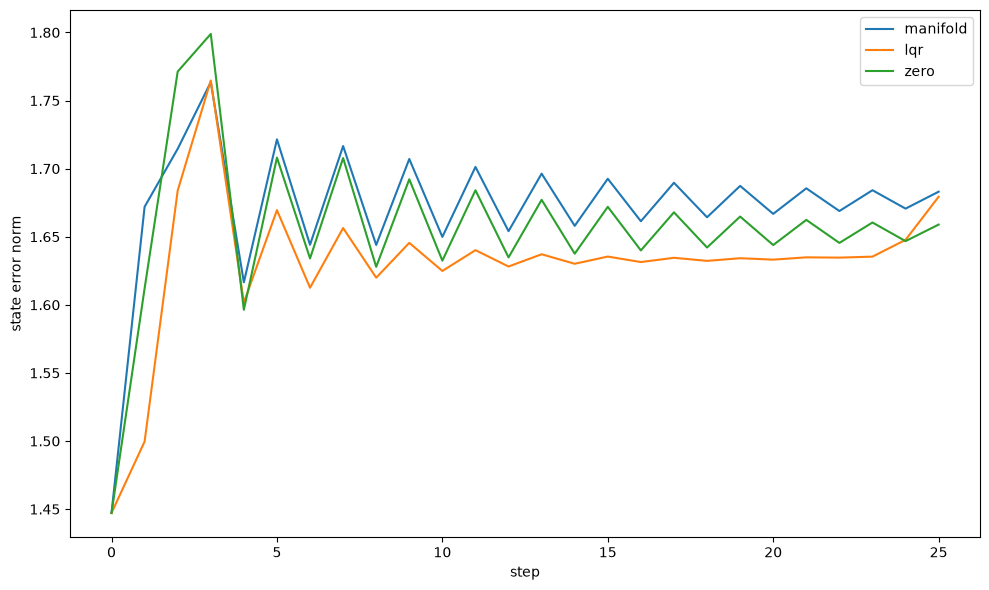

<Figure size 640x480 with 0 Axes>

In [26]:
import matplotlib.pyplot as plt

t = np.arange(sim_steps + 1)

plt.figure(figsize=(10, 6))
plt.plot(t, np.linalg.norm(X_mani - x_ref.reshape(-1, 1), axis=0), label="manifold")
plt.plot(t, np.linalg.norm(X_lqr - x_ref.reshape(-1, 1), axis=0), label="lqr")
plt.plot(t, np.linalg.norm(X_zero - x_ref.reshape(-1, 1), axis=0), label="zero")
plt.xlabel("step")
plt.ylabel("state error norm")
plt.legend()
plt.tight_layout()
plt.show()

plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path)